In [1]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths
from typing import Callable

from pathlib import Path

from numpy.typing import NDArray
import numpy as np
from astropy.io.fits.fitsrec import FITS_rec

from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.mask import count, decode
from bloodmoon.images import argmax

import darksun as ds

ds.show.set_figures_darkbkg()

In [2]:
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "IROSDummy"
DATA_FITS: str = "iros_benchmark_2-50keV_mask_050_1040x17_1ks"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"

UPS_X: int = 10
UPS_Y: int = 4

In [3]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
)
wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)
filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)


# data from camera A
catalogueA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])
sdlA_detct = ds.get_data(filepaths[ID_CAMERA_A]['detected'])
sdlA_recnstr = ds.get_data(filepaths[ID_CAMERA_A]['reconstructed'])

## data from camera B
#catalogueB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])
#sdlB_detct = ds.get_data(filepaths[ID_CAMERA_B]['detected'])
#sdlB_recnstr = ds.get_data(filepaths[ID_CAMERA_B]['reconstructed'])

In [4]:
from bloodmoon.types import CoordEquatorial
from darksun.benchmarking import source_catalogue_data
from darksun.data import CatalogueLoader

type EnergyRange = tuple[float, float]


def get_source_coords(
    sourceID: str,
    catalogue: CatalogueLoader,
) -> CoordEquatorial:
    """Extracts the source RA/Dec coords from catalogue."""
    data = source_catalogue_data(sourceID, catalogue.DLdata)
    return CoordEquatorial(data['RA'], data['DEC'])

def filter_energy(
    photons: FITS_rec,
    E_min: float | None,
    E_max: float | None,
) -> FITS_rec:
    """Filters the input photons by energy, in [keV]."""
    return ds.filter_data(photons, E_min=E_min, E_max=E_max, coords=None)

In [ ]:
from dataclasses import dataclass

from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit
from scipy.signal import convolve

@dataclass
class OptParams:
    """Optimisation results."""
    params: NDArray
    covar: NDArray


#def process_skyimg(
#    camera: CodedMaskCamera,
#    sky: NDArray,
#    pos: tuple[int, int],
#    offset: tuple[int, int],
#) -> NDArray:
#    """
#    Processes the sky image for optimisation.
#    """
#    _slit_x, _slit_y = ds.psf_extension(camera)
#    crop_y, crop_x = _slit_y + offset[0], _slit_x + offset[1]
#    i, j = pos
#    slice_y, slice_x = (
#        slice(i - crop_y, i + crop_y + 1),
#        slice(j - crop_x, j + crop_x + 1),
#    )
#    cropped = sky[slice_y, slice_x]
#    return cropped.flatten()


def config_func(
    camera: CodedMaskCamera,
    detected: NDArray,
    #arg_sky: tuple[int, int],
    #offset: tuple[int, int],
) -> Callable[[NDArray, float, float, float], NDArray]:
    """
    Initialises the kernel model.
    """
    # we take a whole slit to have a good kernel spatial extension
    px_ydim = camera.specs.mask_deltay / camera.upscale_f.y
    slit_dim = camera.specs.slit_deltay
    # the kernel must have the same binning as the mask elements
    bins = np.linspace(-slit_dim, slit_dim, int(2 * slit_dim / px_ydim) + 1)
    
    def _wfm_kernel(alpha: float, beta: float, sigma: float) -> NDArray:
        """LEM-X detector spatial resolution kernel."""        
        PSFY_GAUSS_PARAMS = {
            'mode': 'constant',
            'cval': 0.0,
        }
        modsec = 1.0 / np.cosh(np.abs(bins / alpha) ** beta)
        kernel = modsec.reshape(len(bins), -1)
        # from tests, the modsech should be modulated with a Gaussian
        psfy = gaussian_filter(kernel, sigma, **PSFY_GAUSS_PARAMS)
        return psfy / np.sum(psfy)

    def f(x: NDArray, alpha: float, beta: float, sigma: float) -> NDArray:
        """Models the PSFY kernel and performs the convolution with detected array."""
        conv = convolve(detected, _wfm_kernel(alpha, beta, sigma), mode="same")
        #sky = decode(camera, conv)
        #return process_skyimg(camera, sky, arg_sky, offset)
        return conv.flatten()
    
    return f


def kernel_params_fit(
    camera: CodedMaskCamera,
    detected: NDArray,
    reconstructed: NDArray,
    #arg_sky: tuple[int, int],
    #offset: tuple[int, int],
    verbose: bool = True,
) -> OptParams:
    """Performs the fit of the detector spatial resolution kernel params."""
    # setup skies
    #_sky = decode(camera, reconstructed)
    #ydata = process_skyimg(camera, _sky, arg_sky, offset)
    ydata = reconstructed.flatten()
    # setup func
    #func = config_func(camera, detected, arg_sky, offset)
    func = config_func(camera, detected)
    # setup p0 from current kernel (alpha, beta, sigma)
    start_params_vals = np.array([0.54597, 0.73634, 0.17750])
    # setup boundaries
    bounds = [
        (0.0, 0.0, 0.0),
        (1.0, 1.0, 10.0),
    ]
    # setup least squares kwargs
    lsq_kwargs = {
        'jac': '3-point',
        'ftol': 1e-8,
        'xtol': 1e-8,
        'x_scale': 'jac',
        'loss': 'linear',
    }
    # perform optimisation
    popt, pcov, info, msg, iflag = curve_fit(
        f=func,
        xdata=np.arange(len(ydata)),
        ydata=ydata,
        p0=start_params_vals,
        bounds=bounds,
        method='trf',
        full_output=True,
        **lsq_kwargs,
    )
    if verbose:
        a_start, b_start, s_start = map(float, start_params_vals)
        a, b, s = map(float, popt)
        da, db, dsigma = map(float, np.sqrt(np.diag(pcov)))
        print(
            f'\n'
            f'## Optimisation Results:\n'
            f'  - alpha, beta, sigma START: {a_start, b_start, s_start}\n'

            f'  - alpha OPTIM.: {a} +/- {da}\n'
            f'  - beta OPTIM.: {b} +/- {db}\n'
            f'  - sigma OPTIM.: {s} +/- {dsigma}\n'

            f'  - alpha GAIN: {(a - a_start) * 100 / a_start:.3f}%\n'
            f'  - beta GAIN: {(b - b_start) * 100 / b_start:.3f}%\n'
            f'  - sigma GAIN: {(s - s_start) * 100 / s_start:.3f}%'
        )
        routine_status = [
            'Convergence in chi-square values',
            'Convergence in parameter values',
            'Convergence in both chi-square and parameter values',
            'Convergence in orthogonality',
        ]
        print(
            f'## Fit Report:\n'
            f'  - func calls (also # of iters): {info['nfev']}\n'
            f'  - procedure msg (`ftol`, `xtol` = {lsq_kwargs['ftol']}, {lsq_kwargs['xtol']}): {msg}\n'
            f'  - success status {iflag}: {routine_status[iflag - 1]}\n'
        )

    return OptParams(popt, pcov)

In [6]:
eband: EnergyRange = (2.0, 3.0)  # [keV]

eband_phs_detct: FITS_rec = filter_energy(sdlA_detct.DLdata, *eband)
eband_phs_recnstr: FITS_rec = filter_energy(sdlA_recnstr.DLdata, *eband)

In [ ]:
sourceID: str = 's17'
coords: CoordEquatorial = get_source_coords(sourceID, catalogueA)

phs_detct: FITS_rec = ds.select_source_photons(coords, eband_phs_detct, False)
phs_recnstr: FITS_rec = ds.select_source_photons(coords, eband_phs_recnstr, False)


detected: NDArray = count(wfm, phs_detct)[0]
sky_detected = decode(wfm, detected)

reconstructed: NDArray = count(wfm, phs_recnstr)[0]
sky_reconstructed = decode(wfm, reconstructed)

#arg_sky: tuple[int, int] = argmax(sky_detected)
#offset: tuple[int, int] = (
#    5 * wfm.upscale_f.y,
#    2 * wfm.upscale_f.x,
#)

## USING BULK MASK with 1.5 mm cover ##


In [ ]:
#params: OptParams = kernel_params_fit(wfm, detected, reconstructed, arg_sky, offset)
params: OptParams = kernel_params_fit(wfm, detected, reconstructed)

KeyboardInterrupt: 

In [ ]:
assert False

AssertionError: 

In [ ]:
from bloodmoon.images import fshift
from bloodmoon.mask import decode
from bloodmoon.optim import _detector_footprint_cached
from bloodmoon.optim import apply_vignetting

type CoordSky = tuple[float, float]


def _project_mask_pattern(
    camera: CodedMaskCamera,
    shift_x: float,
    shift_y: float,
) -> NDArray:
    """Projects the camera mask pattern on the detector plane."""
    pxdimy, pxdimx = (
        camera.specs.mask_deltay / camera.upscale_f.y,
        camera.specs.mask_deltax / camera.upscale_f.x,
    )
    fr, fc = (
        (-1.0) * shift_y / pxdimy,
        (-1.0) * shift_x / pxdimx,
    )
    mask_shifted = fshift(camera.mask.astype(float), fr, fc)
    return mask_shifted

def _process_mask_pattern(
    camera: CodedMaskCamera,
    mask_pattern: NDArray,
    shift_x: float,
    shift_y: float,
    vignetting: bool,
    psfy: bool,
) -> NDArray:
    """Applies instrumental effects to the mask pattern projection."""
    mp_vignetted: NDArray = (
        apply_vignetting(camera, mask_pattern, shift_x, shift_y)
        if vignetting else mask_pattern
    )
    mp_psfy: NDArray = (
        apply_detector_resolution(camera, mp_vignetted)
        if psfy else mp_vignetted
    )
    return mp_psfy

def _extract_detector(
    camera: CodedMaskCamera,
    mask_projection: NDArray,
) -> NDArray:
    """
    Extracts the detector image from the mask pattern projection on the detector plane.
    """
    i_min, i_max, j_min, j_max = _detector_footprint_cached(camera)
    detector = mask_projection[i_min:i_max, j_min:j_max]
    detector *= camera.bulk
    detector /= np.sum(detector)
    return detector


def model_source_sg(
    camera: CodedMaskCamera,
    params: dict[EnergyRange, CoordSky],
    vignetting: bool = True,
    psfy: bool = True,
) -> NDArray:
    """
    Generates a source detector image as superimposition
    of shadowgrams in given energy bands.
    """
    detector: NDArray = np.zeros(camera.shape_detector)
    for frc, shifts in zip(flx_fracts, tuple(params.values())):
        # shift mask pattern wrt the energy band
        _shifted = _project_mask_pattern(camera, *shifts)
        # apply instr effects
        _processed = _process_mask_pattern(camera, _shifted, _sx, _sy, vignetting, psfy)
        # extract source detector image and weight it with eband flux fraction
        detector += (frc * _extract_detector(camera, _processed))
    
    return detector


def model_source_sky(
    camera: CodedMaskCamera,
    params: dict[EnergyRange, CoordSky],
    counts: float,
    vignetting: bool = True,
    psfy: bool = True,
) -> NDArray:
    """Generate a model of the reconstructed sky image for a point source."""
    detector = model_source_sg(
        camera, params, vignetting=vignetting, psfy=psfy,
    )
    return decode(camera, counts * detector)

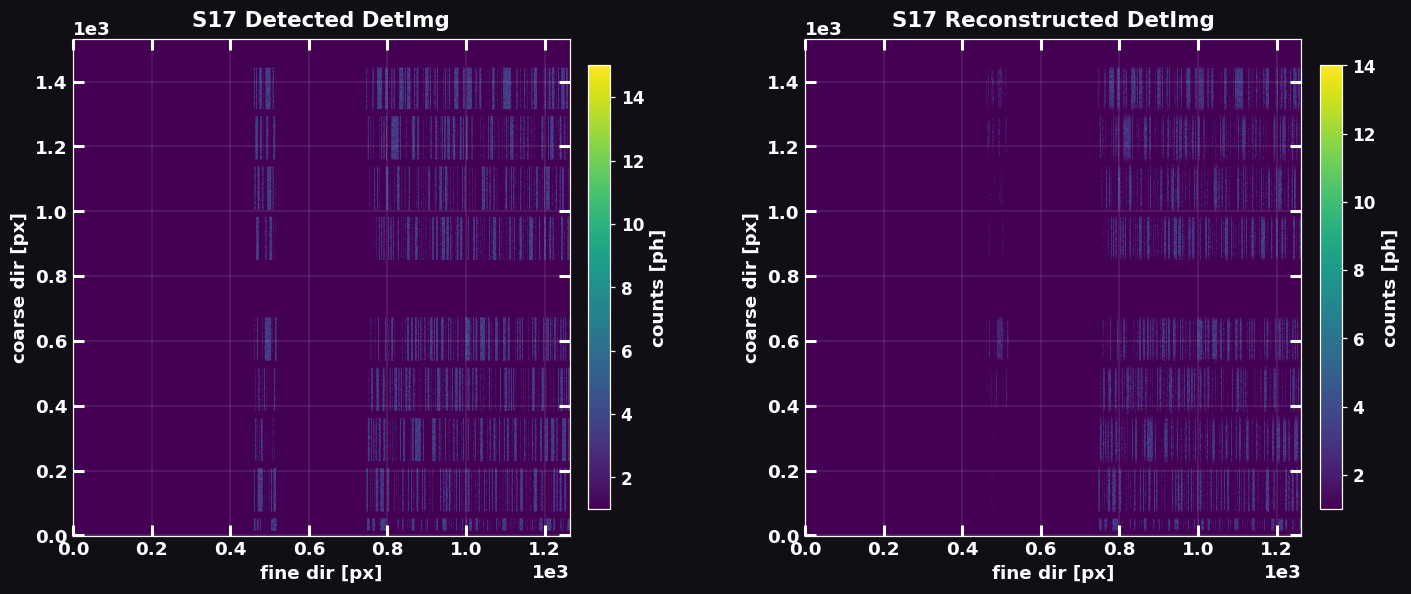

In [ ]:
_cbarcloc = 'right'
_aspect = wfm.shape_detector[1] / wfm.shape_detector[0]
_imgkwargs: dict = {
    'aspect': _aspect,
    'vmin': 1,
}
ds.image_plot(
    dmaps=(
        ds.map4image(
            img=detected,
            title=f'{sourceID.upper()} Detected DetImg',
            xlabel='fine dir [px]',
            ylabel='coarse dir [px]',
            cbarlabel='counts [ph]',
            cbarloc=_cbarcloc,
            img_kwargs=_imgkwargs,
        ),
        ds.map4image(
            img=reconstructed,
            title=f'{sourceID.upper()} Reconstructed DetImg',
            xlabel='fine dir [px]',
            ylabel='coarse dir [px]',
            cbarlabel='counts [ph]',
            cbarloc=_cbarcloc,
            img_kwargs=_imgkwargs,
        ),
    ),
    ncols=2,
)

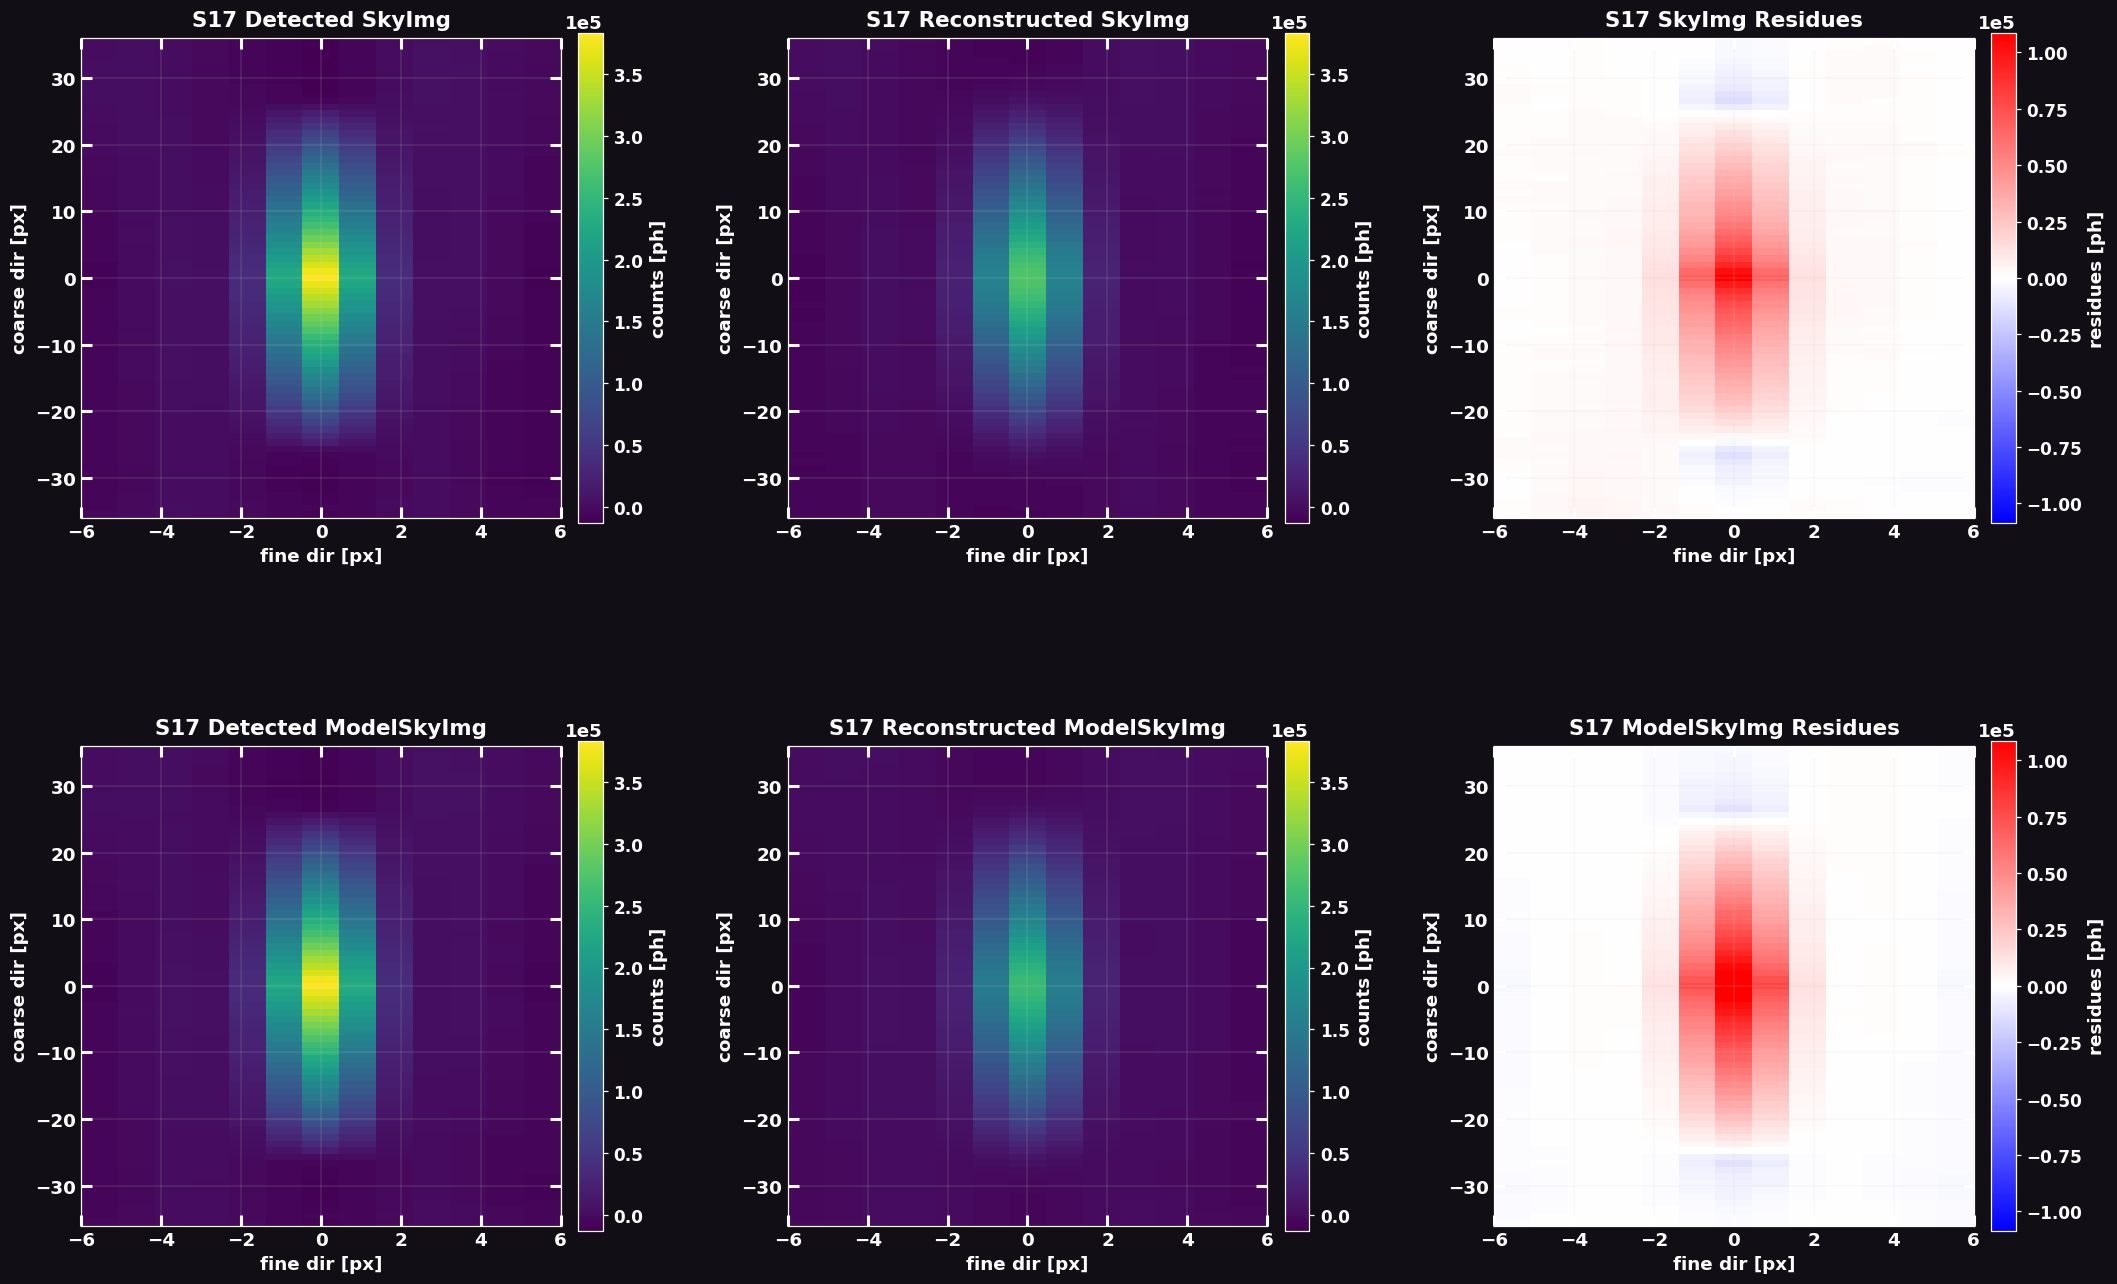

In [ ]:
from bloodmoon.coords import equatorial2shift
from bloodmoon.optim import model_sky


pos = argmax(sky_detected)
_fine, _coarse = ds.psf_extension(wfm)
crp = (
    _coarse + offset[0], _fine + offset[1],
)

det_crpd = ds.crop(sky_detected, pos, crp)
recns_crpd = ds.crop(sky_reconstructed, pos, crp)
_imgkwargs: dict = {
    'aspect': crp[1] / crp[0],
    'extent': [-crp[1], crp[1], -crp[0], crp[0]],
    'vmin': det_crpd.min(),
    'vmax': det_crpd.max(),
}
res = det_crpd - recns_crpd
vlim = np.max(np.abs(res))
true_dmaps = (
    ds.map4image(
        img=det_crpd,
        title=f'{sourceID.upper()} Detected SkyImg',
        xlabel='fine dir [px]',
        ylabel='coarse dir [px]',
        cbarlabel='counts [ph]',
        cbarloc=_cbarcloc,
        img_kwargs=_imgkwargs,
    ),
    ds.map4image(
        img=recns_crpd,
        title=f'{sourceID.upper()} Reconstructed SkyImg',
        xlabel='fine dir [px]',
        ylabel='coarse dir [px]',
        cbarlabel='counts [ph]',
        cbarloc=_cbarcloc,
        img_kwargs=_imgkwargs,
    ),
    ds.map4image(
        img=res,
        title=f'{sourceID.upper()} SkyImg Residues',
        xlabel='fine dir [px]',
        ylabel='coarse dir [px]',
        cbarlabel='residues [ph]',
        cbarloc=_cbarcloc,
        img_kwargs={
            **_imgkwargs,
            'vmin': -vlim,
            'vmax': vlim,
            'cmap': 'bwr',
        },
    ),
)


shift_x, shift_y = equatorial2shift(sdlA_detct, wfm, *coords)
model_detected = model_sky(wfm, shift_x, shift_y, det_crpd.max(), psfy=False)
model_reconstructed = model_sky(wfm, shift_x, shift_y, recns_crpd.max(), psfy=True)

det_model_crpd = ds.crop(model_detected, pos, crp)
recns_model_crpd = ds.crop(model_reconstructed, pos, crp)
model_res = det_model_crpd - recns_model_crpd

model_dmaps = (
    ds.map4image(
        img=det_model_crpd,
        title=f'{sourceID.upper()} Detected ModelSkyImg',
        xlabel='fine dir [px]',
        ylabel='coarse dir [px]',
        cbarlabel='counts [ph]',
        cbarloc=_cbarcloc,
        img_kwargs=_imgkwargs,
    ),
    ds.map4image(
        img=recns_model_crpd,
        title=f'{sourceID.upper()} Reconstructed ModelSkyImg',
        xlabel='fine dir [px]',
        ylabel='coarse dir [px]',
        cbarlabel='counts [ph]',
        cbarloc=_cbarcloc,
        img_kwargs=_imgkwargs,
    ),
    ds.map4image(
        img=model_res,
        title=f'{sourceID.upper()} ModelSkyImg Residues',
        xlabel='fine dir [px]',
        ylabel='coarse dir [px]',
        cbarlabel='residues [ph]',
        cbarloc=_cbarcloc,
        img_kwargs={
            **_imgkwargs,
            'vmin': -vlim,
            'vmax': vlim,
            'cmap': 'bwr',
        },
    ),
)

ds.image_plot(
    dmaps=(*true_dmaps, *model_dmaps),
    ncols=3,
    nrows=2,
)

assert argmax(det_crpd) == argmax(recns_crpd)

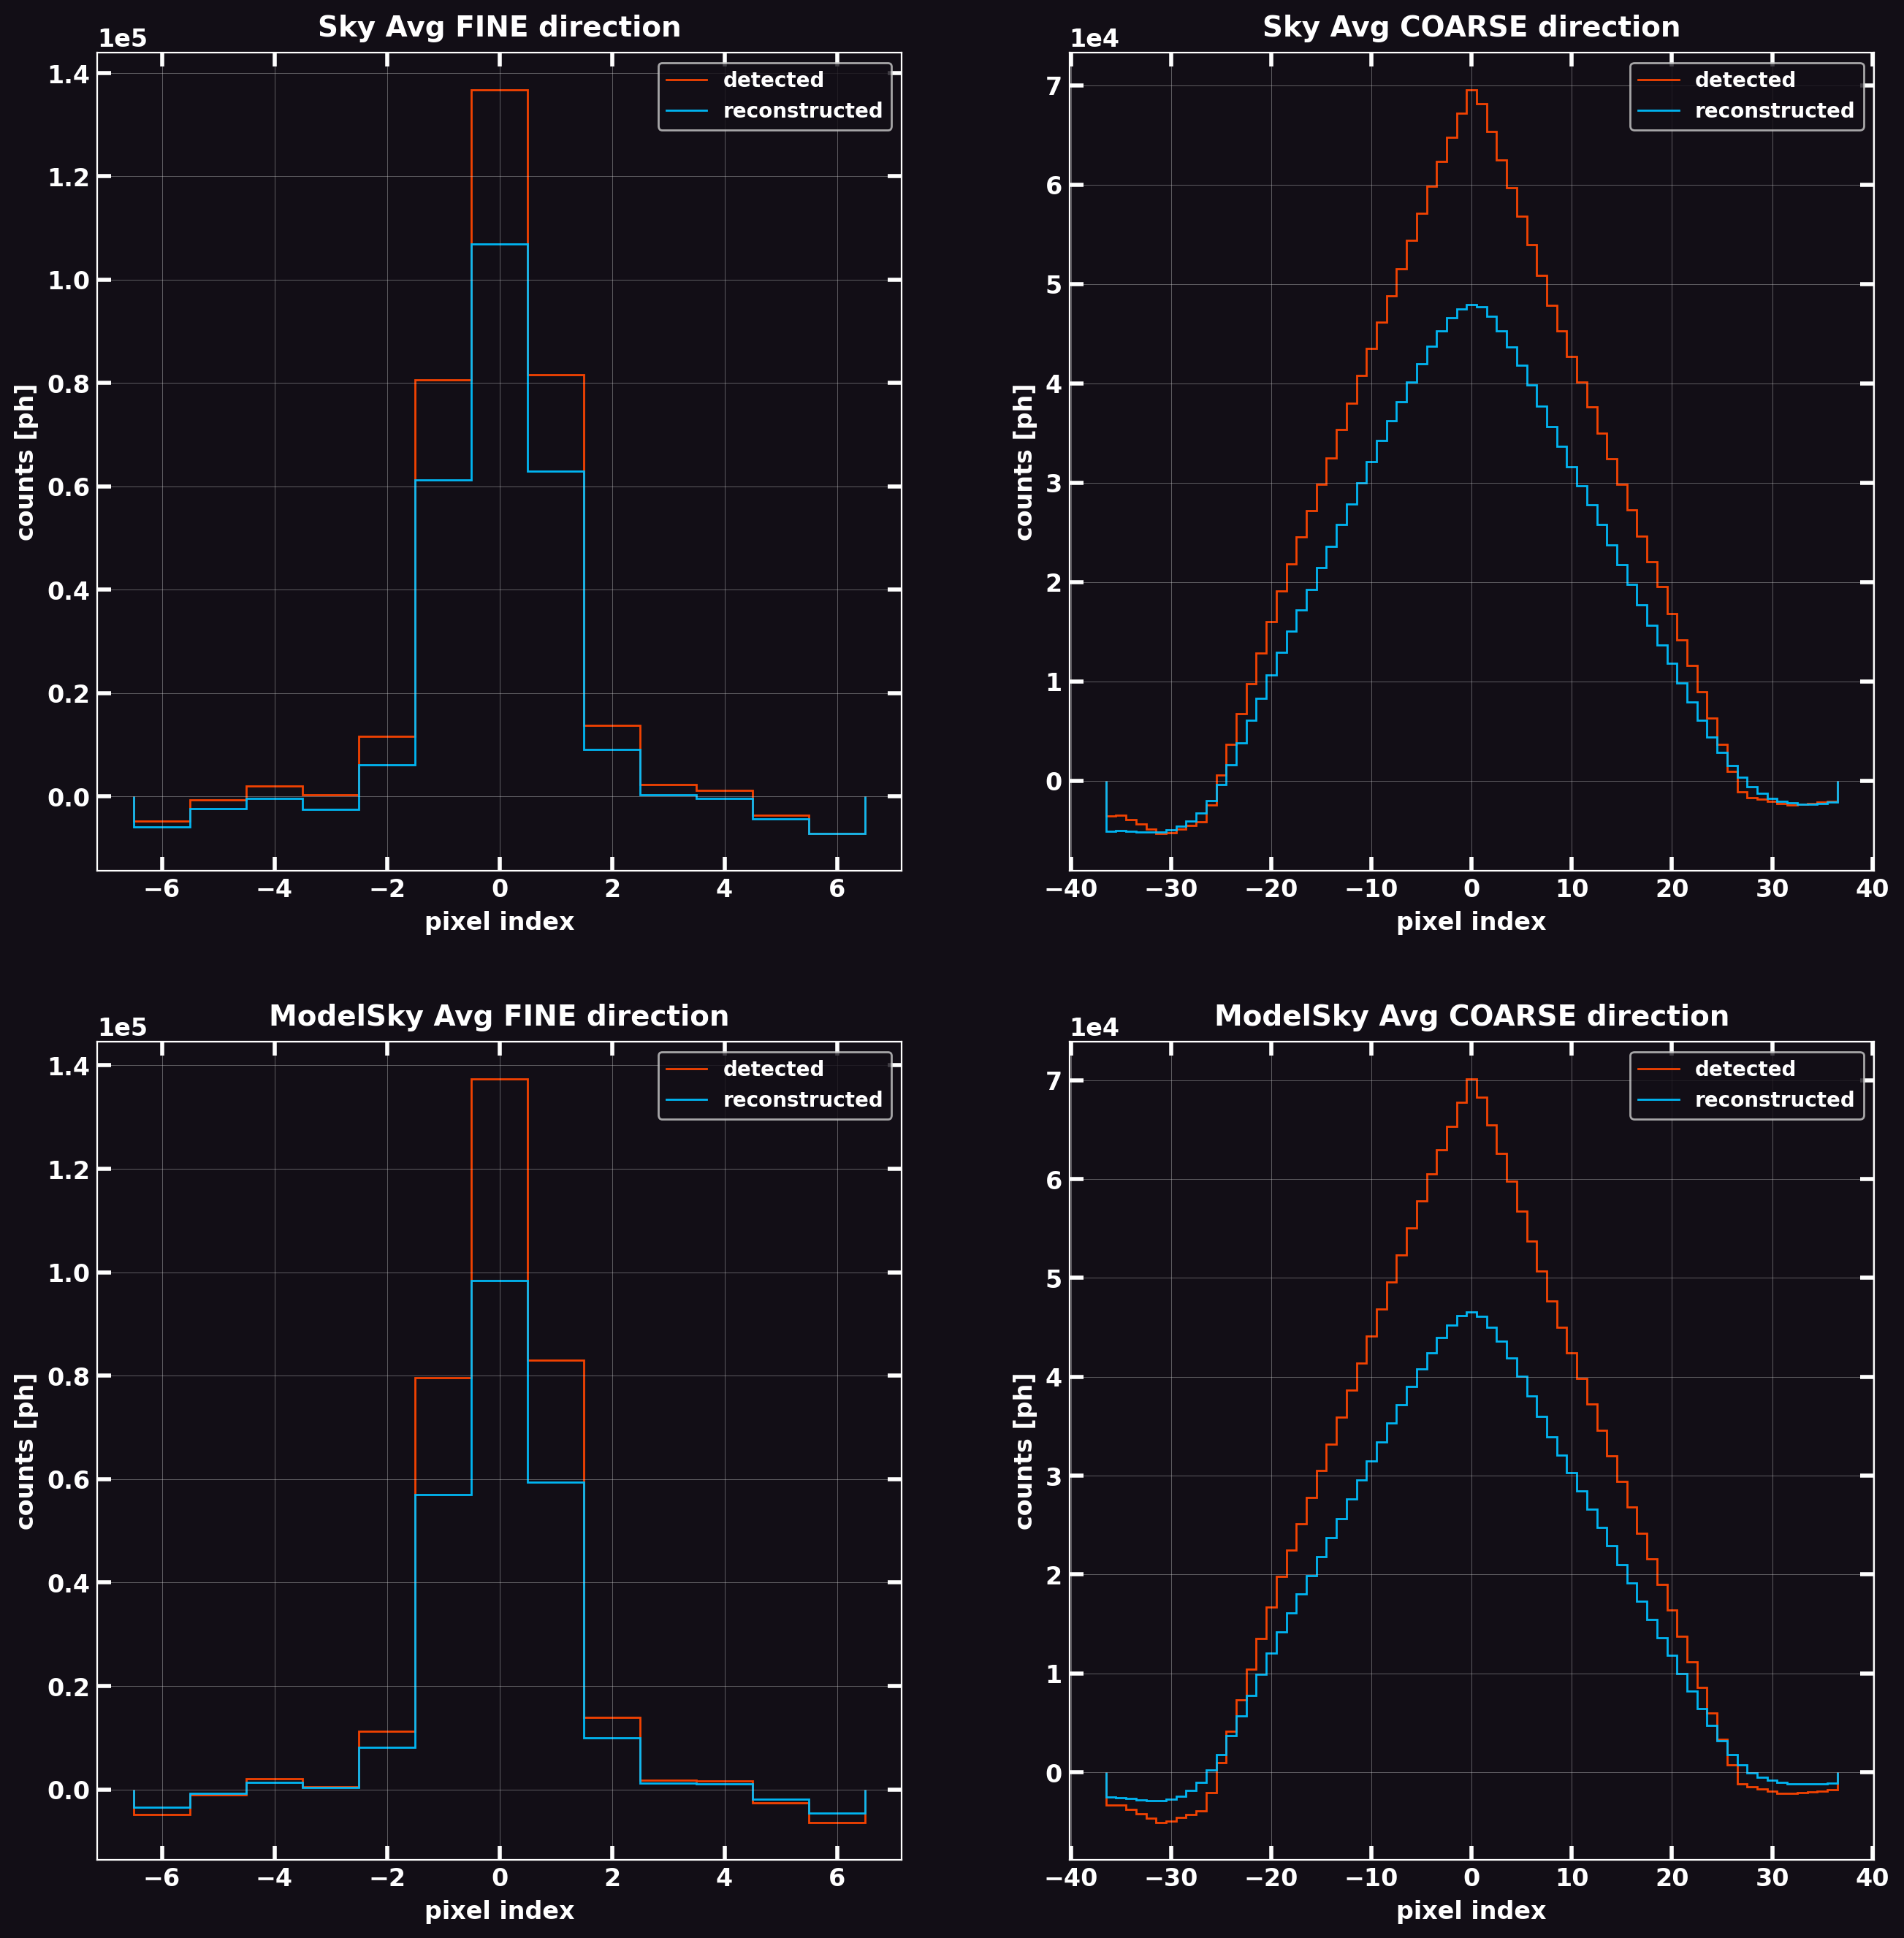

In [ ]:
from typing import Any

def collapse_view(
    arr: NDArray,
    method: Callable[[NDArray, Any], NDArray] = np.sum,
) -> tuple[NDArray, NDArray]:
    """
    Collapses the elements of a 2D array by applying
    the given method along the (col, row) array axes.

    Returns:
        output (tuple[NDArray, NDArray]):
            - collapsed array along the row axis
            - collapsed array along the col axis
    
    ## Notes:
        - if `arr.shape = (n, m)`, the collapsed array
          along row has length `m`, while the collapsed
          array along col has length `n`.
    """
    return method(arr, axis=0), method(arr, axis=1)

det_crpd_x, det_crpd_y = collapse_view(det_crpd, np.mean)
recns_crpd_x, recns_crpd_y = collapse_view(recns_crpd, np.mean)

det_model_crpd_x, det_model_crpd_y = collapse_view(det_model_crpd, np.mean)
recns_model_crpd_x, recns_model_crpd_y = collapse_view(recns_model_crpd, np.mean)

_phase_fine = np.arange(len(det_crpd_x) + 1) - len(det_crpd_x) // 2 - 0.5
_phase_coarse = np.arange(len(det_crpd_y) + 1) - len(det_crpd_y) // 2 - 0.5

data_dmap_collapsed_x = ds.map4plot(
    arrs=(det_crpd_x, recns_crpd_x),
    title='Sky Avg FINE direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detected', 'reconstructed'),
    x=_phase_fine,
    color=('OrangeRed', 'DeepSkyBlue'),
    style='stairs',
)
data_dmap_collapsed_y = ds.map4plot(
    arrs=(det_crpd_y, recns_crpd_y),
    title='Sky Avg COARSE direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detected', 'reconstructed'),
    x=_phase_coarse,
    color=('OrangeRed', 'DeepSkyBlue'),
    style='stairs',
)

datamodel_dmap_collapsed_x = ds.map4plot(
    arrs=(det_model_crpd_x, recns_model_crpd_x),
    title='ModelSky Avg FINE direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detected', 'reconstructed'),
    x=_phase_fine,
    color=('OrangeRed', 'DeepSkyBlue'),
    style='stairs',
)
datamodel_dmap_collapsed_y = ds.map4plot(
    arrs=(det_model_crpd_y, recns_model_crpd_y),
    title='ModelSky Avg COARSE direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detected', 'reconstructed'),
    x=_phase_coarse,
    color=('OrangeRed', 'DeepSkyBlue'),
    style='stairs',
)

ds.plot(
    dmaps=(
        data_dmap_collapsed_x, data_dmap_collapsed_y,
        datamodel_dmap_collapsed_x, datamodel_dmap_collapsed_y,
    ),
    ncols=2,
    nrows=2,
)

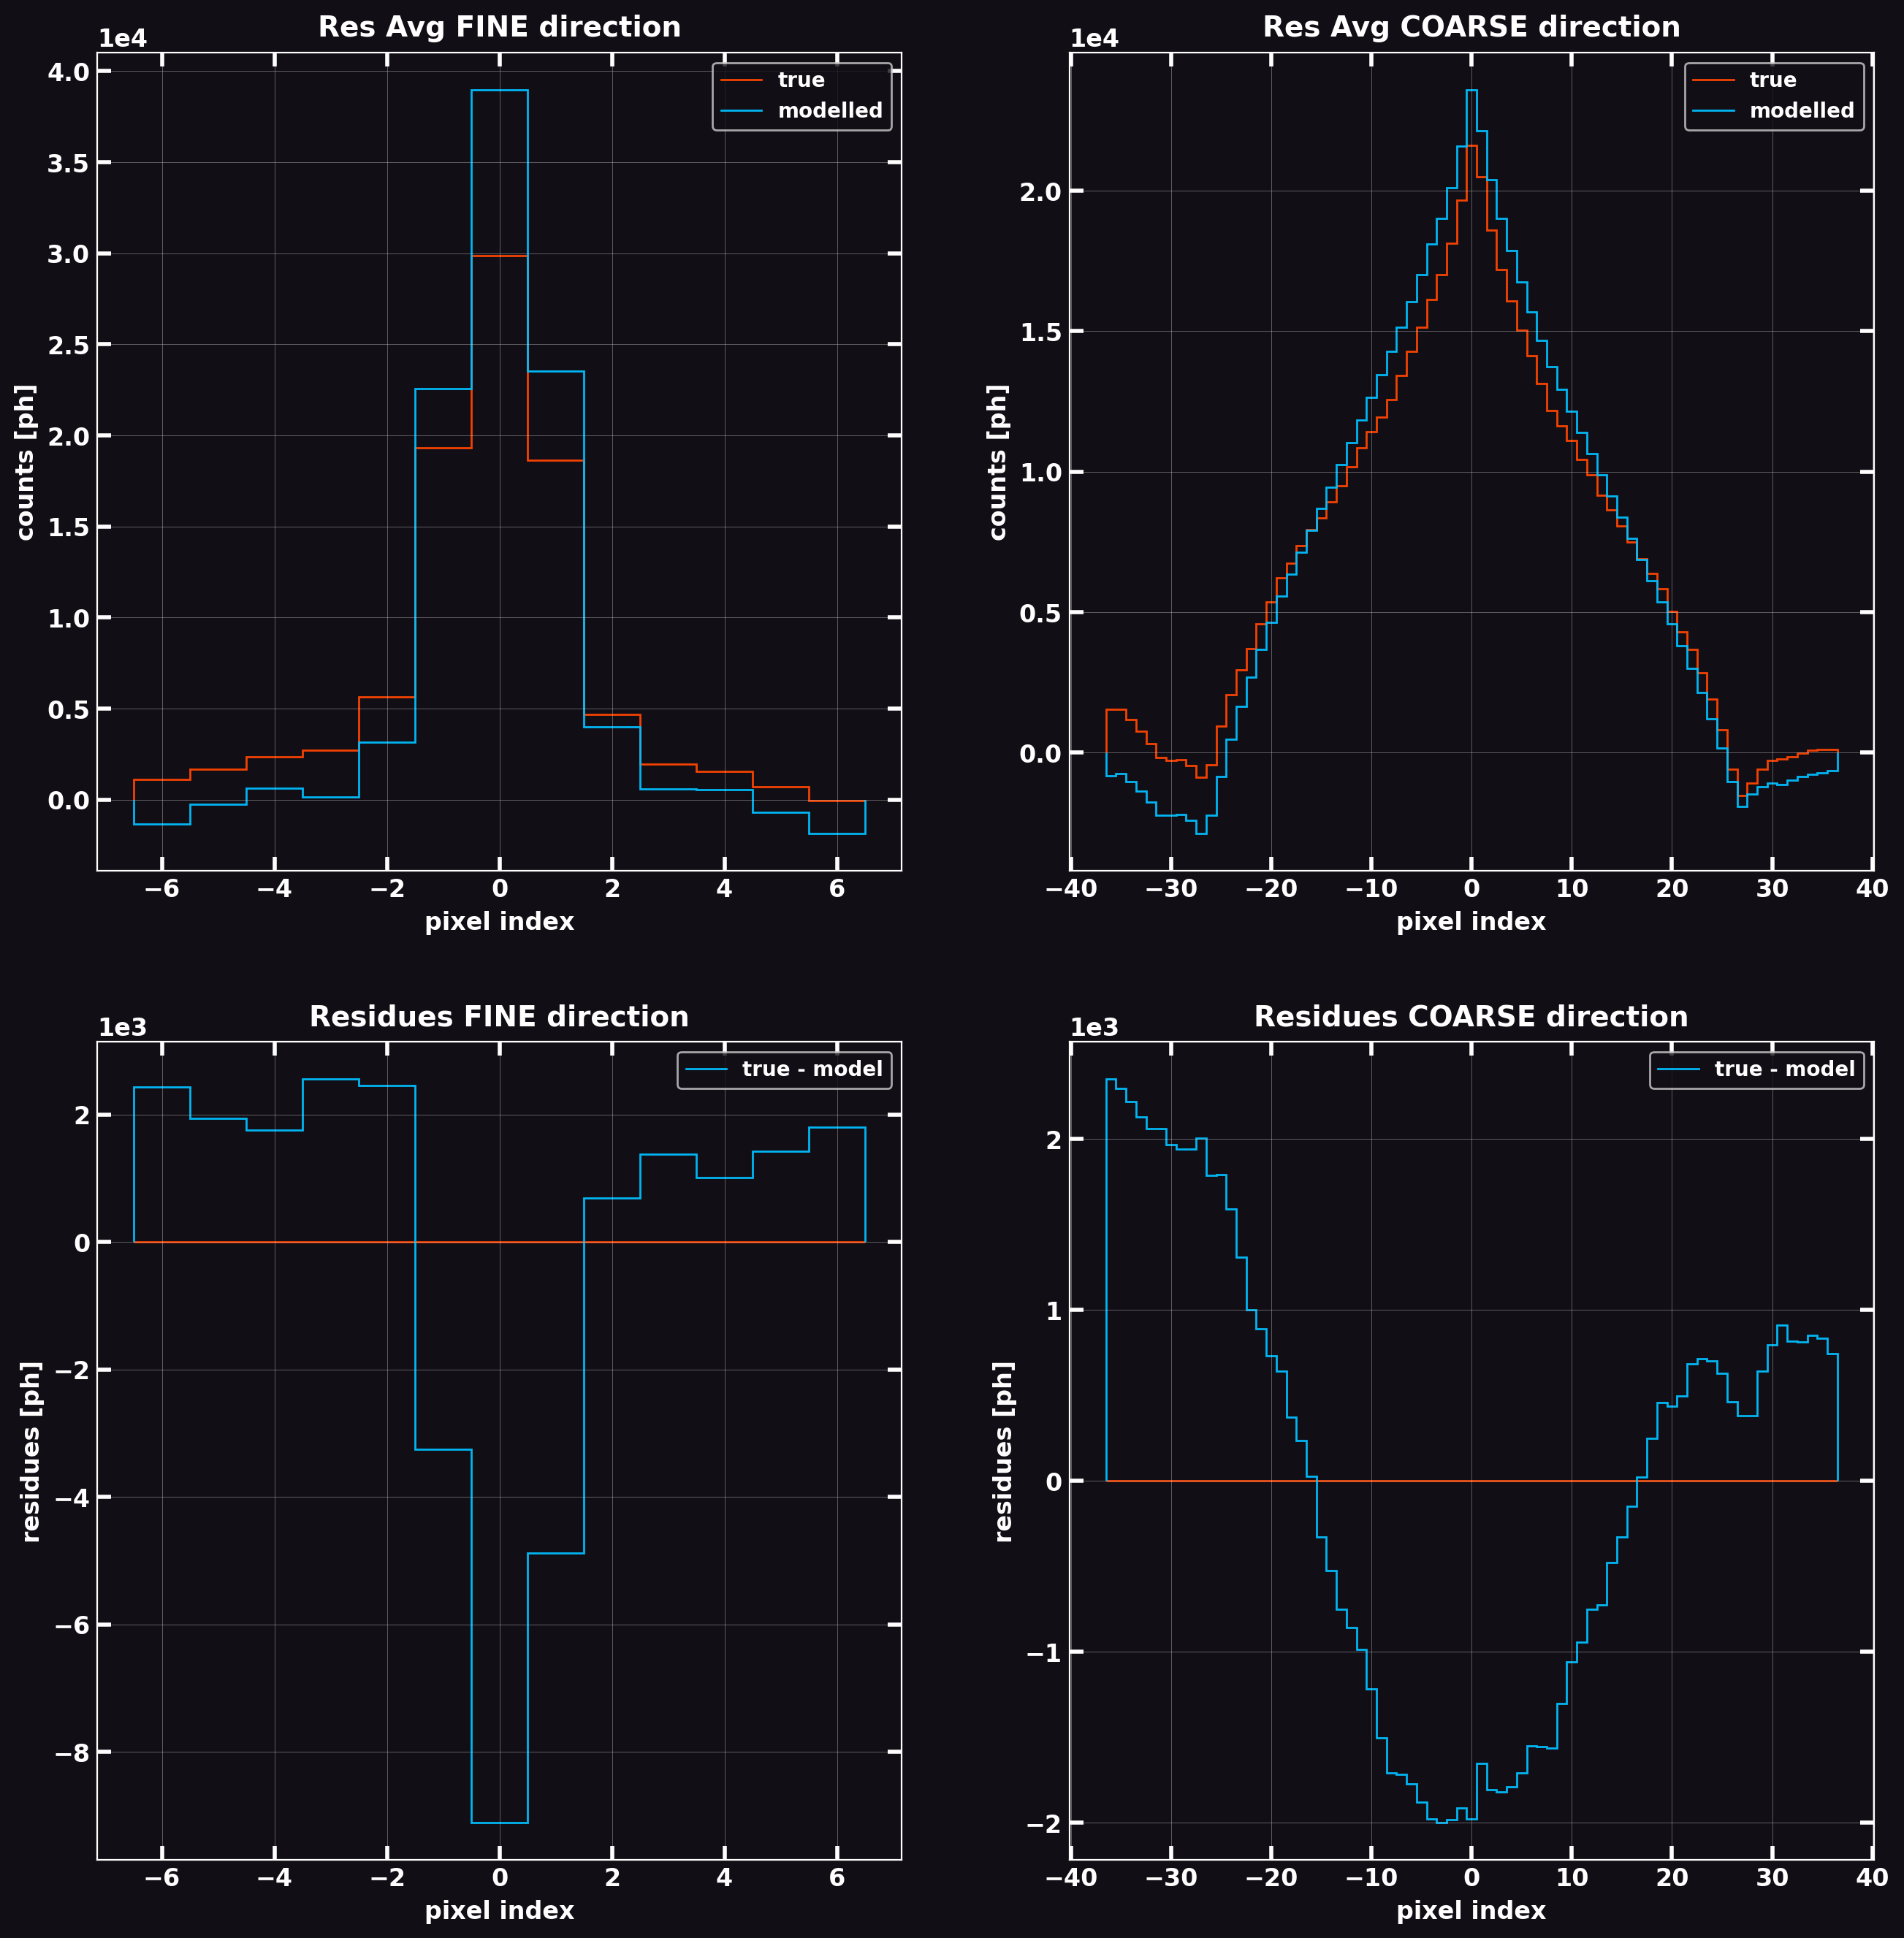

In [ ]:
res_x, res_y = collapse_view(res, method=np.mean)
model_res_x, model_res_y = collapse_view(model_res, method=np.mean)

dmap_collapsed_x = ds.map4plot(
    arrs=(res_x, model_res_x),
    title='Res Avg FINE direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('true', 'modelled'),
    x=_phase_fine,
    color=('OrangeRed', 'DeepSkyBlue'),
    style='stairs',
)
resdmap_collapsed_x = ds.map4plot(
    arrs=(np.zeros_like(res_x), res_x - model_res_x),
    title='Residues FINE direction',
    ylabel='residues [ph]',
    xlabel='pixel index',
    labels=('', 'true - model'),
    x=_phase_fine,
    color=('OrangeRed', 'DeepSkyBlue'),
    style='stairs',
)
dmap_collapsed_y = ds.map4plot(
    arrs=(res_y, model_res_y),
    title='Res Avg COARSE direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('true', 'modelled'),
    x=_phase_coarse,
    color=('OrangeRed', 'DeepSkyBlue'),
    style='stairs',
)
resdmap_collapsed_y = ds.map4plot(
    arrs=(np.zeros_like(res_y), res_y - model_res_y),
    title='Residues COARSE direction',
    ylabel='residues [ph]',
    xlabel='pixel index',
    labels=('', 'true - model'),
    x=_phase_coarse,
    color=('OrangeRed', 'DeepSkyBlue'),
    style='stairs',
)
ds.plot(
    dmaps=(
        dmap_collapsed_x, dmap_collapsed_y,
        resdmap_collapsed_x, resdmap_collapsed_y,
    ),
    ncols=2,
    nrows=2,
)